In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)   # cố định seed để ai cũng ra cùng kết quả
a = np.array([1, 2, 3, 4])              # từ list
b = np.zeros((3, 4))                    # ma trận 3×4 toàn 0
c = np.ones(5)                          # vector 5 phần tử toàn 1
d = np.arange(0, 10, 2)                 # 0, 2, 4, 6, 8
e = np.linspace(0, 1, 5)                # 5 số đều từ 0 đến 1
f = np.random.rand(3, 3)                # ma trận 3×3 phân phối đều
g = np.random.randn(2, 3)               # ma trận 2×3 phân phối chuẩn

print('a shape:', a.shape, ' dtype:', a.dtype)
print('b =\n', b)
print('e =', e)
print('f =\n', f)
print('g =\n', g)


a shape: (4,)  dtype: int64
b =
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
e = [0.   0.25 0.5  0.75 1.  ]
f =
 [[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]]
g =
 [[-0.58087813 -0.52516981 -0.57138017]
 [-0.92408284 -2.61254901  0.95036968]]


1.2. Reshape, indexing, slicing

In [40]:
x = np.arange(12)            # 0, 1, ..., 11
X = x.reshape(3, 4)
print('X =\n', X)

# Lấy phần tử (giống Python)
print('X[0, 0] =', X[0, 0])      # góc trên trái
print('X[1, 2] =', X[1, 2])      # hàng 1, cột 2

# Slicing: hàng 1, tất cả cột
print('X[1, :] =', X[1, :])

# Cột cuối cùng
print('X[:, -1] =', X[:, -1])

# Boolean indexing — cực kỳ hữu ích
mask = X > 5
print('mask =\n', mask)
print('X[X > 5] =', X[X > 5])

X =
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
X[0, 0] = 0
X[1, 2] = 6
X[1, :] = [4 5 6 7]
X[:, -1] = [ 3  7 11]
mask =
 [[False False False False]
 [False False  True  True]
 [ True  True  True  True]]
X[X > 5] = [ 6  7  8  9 10 11]


1.3. Broadcasting — phép màu của NumPy
Khi cộng hai mảng khác shape, NumPy tự động "kéo" mảng nhỏ ra cho khớp với mảng lớn (chừng nào shape phù hợp). Đây là tính năng giúp code rất ngắn gọn.

In [41]:
M = np.arange(12).reshape(3, 4)        # (3, 4)
v = np.array([10, 20, 30, 40])         # (4,)

# v được broadcast lên thành (3, 4) rồi mới cộng.
print('M + v =\n', M + v)

# Trừ trung bình theo cột (zero-center) — kỹ thuật rất hay dùng trước khi train.
M_centered = M - M.mean(axis=0)
print('M_centered =\n', M_centered)
print('Mean theo cột:', M_centered.mean(axis=0))   # gần 0


M + v =
 [[10 21 32 43]
 [14 25 36 47]
 [18 29 40 51]]
M_centered =
 [[-4. -4. -4. -4.]
 [ 0.  0.  0.  0.]
 [ 4.  4.  4.  4.]]
Mean theo cột: [0. 0. 0. 0.]


1.4. Phép nhân ma trận và dot product
Phân biệt rõ:

* là nhân từng phần tử (element-wise / Hadamard).
@ hoặc np.dot là nhân ma trận theo nghĩa tuyến tính.

In [42]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print('A * B (element-wise) =\n', A * B)
print('A @ B (matrix mul)    =\n', A @ B)

# Dot product cho vector
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])
print('u . v =', u @ v)        # 4 + 10 + 18 = 32

A * B (element-wise) =
 [[ 5 12]
 [21 32]]
A @ B (matrix mul)    =
 [[19 22]
 [43 50]]
u . v = 32


# Mục mới

1.5. Axis — chỗ hay nhầm nhất
Khi gọi mean, sum, argmax... với axis=0 hay axis=1, mới học hay nhầm. Quy tắc đơn giản: axis=0 là gộp theo trục 0 → kết quả mất chiều 0.

Với ma trận 2D: axis=0 gộp các hàng lại (kết quả là 1 hàng); axis=1 gộp các cột lại (kết quả là 1 cột).

In [43]:
X = np.arange(12).reshape(3, 4)
print('X =\n', X)
print('Tổng tất cả        :', X.sum())
print('Tổng theo axis=0 (gộp hàng → 1 hàng):', X.sum(axis=0))   # shape (4,)
print('Tổng theo axis=1 (gộp cột → 1 cột):', X.sum(axis=1))    # shape (3,)
print('Argmax theo axis=1 :', X.argmax(axis=1))                 # vị trí max ở mỗi hàng


X =
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Tổng tất cả        : 66
Tổng theo axis=0 (gộp hàng → 1 hàng): [12 15 18 21]
Tổng theo axis=1 (gộp cột → 1 cột): [ 6 22 38]
Argmax theo axis=1 : [3 3 3]


Bài 1: NumPy cơ bản
Tạo mảng a = np.arange(20). Lấy ra các phần tử ở vị trí chẵn (0, 2, 4...).
Tạo ma trận 5×5 toàn số 0, sau đó đặt 1 trên đường chéo chính (gợi ý: np.eye hoặc gán bằng M[range(5), range(5)] = 1).
Cho M = np.random.randn(4, 5). Tính tổng theo từng hàng, theo từng cột. Kiểm tra shape kết quả có đúng (4,) và (5,) không.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

a = np.arange(0, 20, 2)
print('a =', a)

a = [ 0  2  4  6  8 10 12 14 16 18]


In [45]:
b = np.eye(5)
print(b)

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [46]:
M = np.random.randn(4, 5)
print('M =\n', M)
print('Tổng tất cả        :', M.sum())
print('Tổng theo axis=0 (gộp hàng → 1 hàng):', M.sum(axis=0))   # shape (5,)
print('Tổng theo axis=1 (gộp cột → 1 cột):', M.sum(axis=1))    # shape (4,)
print('Argmax theo axis=1 :', M.argmax(axis=1))

M =
 [[ 0.81644508 -1.523876   -0.42804606 -0.74240684 -0.7033438 ]
 [-2.13962066 -0.62947496  0.59772047  2.55948803  0.39423302]
 [ 0.12221917 -0.51543566 -0.60025385  0.94743982  0.291034  ]
 [-0.63555974 -1.02155219 -0.16175539 -0.5336488  -0.00552786]]
Tổng tất cả        : -3.9119222290150715
Tổng theo axis=0 (gộp hàng → 1 hàng): [-1.83651615 -3.69033882 -0.59233483  2.23087221 -0.02360464]
Tổng theo axis=1 (gộp cột → 1 cột): [-2.58122762  0.7823459   0.24500348 -2.35804399]
Argmax theo axis=1 : [0 3 3 4]


Bài 2: Broadcasting và normalize
Cho X = np.random.randn(100, 4) (100 mẫu, 4 đặc trưng). Hãy chuẩn hoá z-score theo cột: với mỗi cột, trừ trung bình rồi chia độ lệch chuẩn.

Gợi ý: X.mean(axis=0) shape (4,), dùng broadcasting để trừ đi.
Sau khi chuẩn hoá, X_normalized.mean(axis=0) phải gần 0, X_normalized.std(axis=0) phải gần 1.

In [47]:
X = np.random.randn(100, 4)

mean_X = X.mean(axis=0)
std_X = X.std(axis=0)
X_normalized = (X - mean_X) / std_X

In [48]:
print('Mean của X_normalized theo cột:', X_normalized.mean(axis=0))
print('Độ lệch chuẩn của X_normalized theo cột:', X_normalized.std(axis=0))

Mean của X_normalized theo cột: [-5.82173199e-17  7.77156117e-18 -7.77156117e-18 -2.97539771e-16]
Độ lệch chuẩn của X_normalized theo cột: [1. 1. 1. 1.]


Bài 3: Pandas — phân tích Iris
Đọc file Iris.csv (trong thư mục 1. PyTorch/). Trả lời:

Có bao nhiêu dòng, bao nhiêu cột?
Trung bình sepal.length theo từng loài (variety) là bao nhiêu? (gợi ý: groupby)
Loài nào có petal.width lớn nhất?
Vẽ scatter plot 2D (sepal.length vs petal.length), tô màu theo loài.

,Id,sepal.length,sepal.width,petal.length,petal.width,variety
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Số dòng: 150, Số cột: 6

Trung bình sepal.length theo loài:
 variety
Iris-setosa        5.006
Iris-versicolor    5.936
Iris-virginica     6.588
Name: sepal.length, dtype: float64

Loài có petal.width lớn nhất là: Iris-virginica


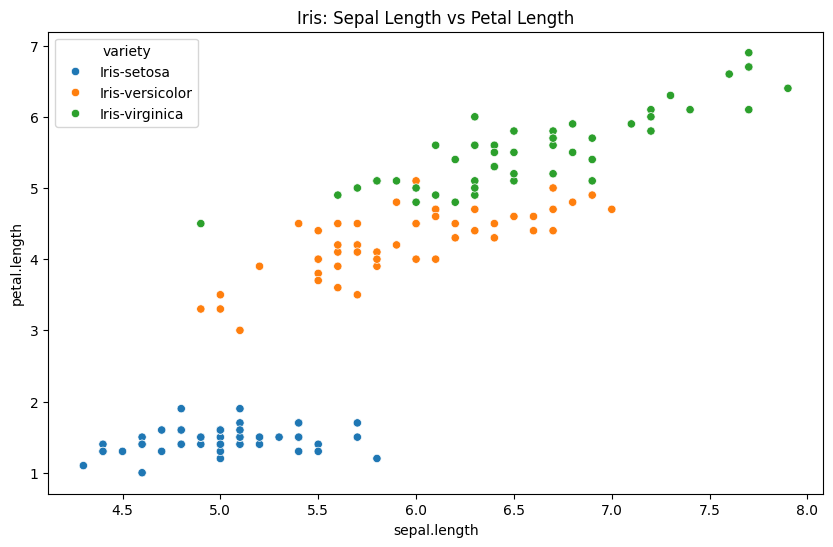

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Đọc dữ liệu
iris_path = 'Iris.csv'
if os.path.exists(iris_path):
    df = pd.read_csv(iris_path)
    # Chuẩn hóa tên cột phổ biến
    column_mapping = {
        'SepalLengthCm': 'sepal.length',
        'SepalWidthCm': 'sepal.width',
        'PetalLengthCm': 'petal.length',
        'PetalWidthCm': 'petal.width',
        'Species': 'variety'
    }
    df = df.rename(columns=column_mapping)
else:
    # Fallback nếu không có file local
    from sklearn.datasets import load_iris
    iris = load_iris()
    df = pd.DataFrame(iris.data, columns=['sepal.length', 'sepal.width', 'petal.length', 'petal.width'])
    df['variety'] = [iris.target_names[i] for i in iris.target]

display(df.head())

# Trả lời các câu hỏi:
# Q1: Số dòng, số cột
print(f'Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}')

# Q2: Trung bình sepal.length theo loài
variety_col = 'variety'
length_col = 'sepal.length'
avg_sepal_length = df.groupby(variety_col)[length_col].mean()
print('\nTrung bình sepal.length theo loài:\n', avg_sepal_length)

# Q3: Loài có petal.width lớn nhất
width_col = 'petal.width'
max_idx = df[width_col].idxmax()
max_variety = df.loc[max_idx, variety_col]
print(f'\nLoài có petal.width lớn nhất là: {max_variety}')

# Q4: Vẽ scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sepal.length', y='petal.length', hue='variety')
plt.title('Iris: Sepal Length vs Petal Length')
plt.show()

Bài 4: Matplotlib — vẽ learning curve giả
Sinh dữ liệu giả lập:

epochs = np.arange(1, 51)
train_loss = 1.0 * np.exp(-epochs/10) + np.random.randn(50) * 0.02
test_loss  = 1.0 * np.exp(-epochs/12) + np.random.randn(50) * 0.03 + 0.05
Vẽ subplot 1×2:

Trái: train_loss và test_loss qua epoch.
Phải: histogram của các giá trị train_loss.
Có legend, label trục, title rõ ràng, grid mờ.

In [50]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 51)
train_loss = 1.0 * np.exp(-epochs/10) + np.random.randn(50) * 0.02
test_loss  = 1.0 * np.exp(-epochs/12) + np.random.randn(50) * 0.03 + 0.05

print('Đã cập nhật dữ liệu giả lập cho Bài 4.')

Đã cập nhật dữ liệu giả lập cho Bài 4.


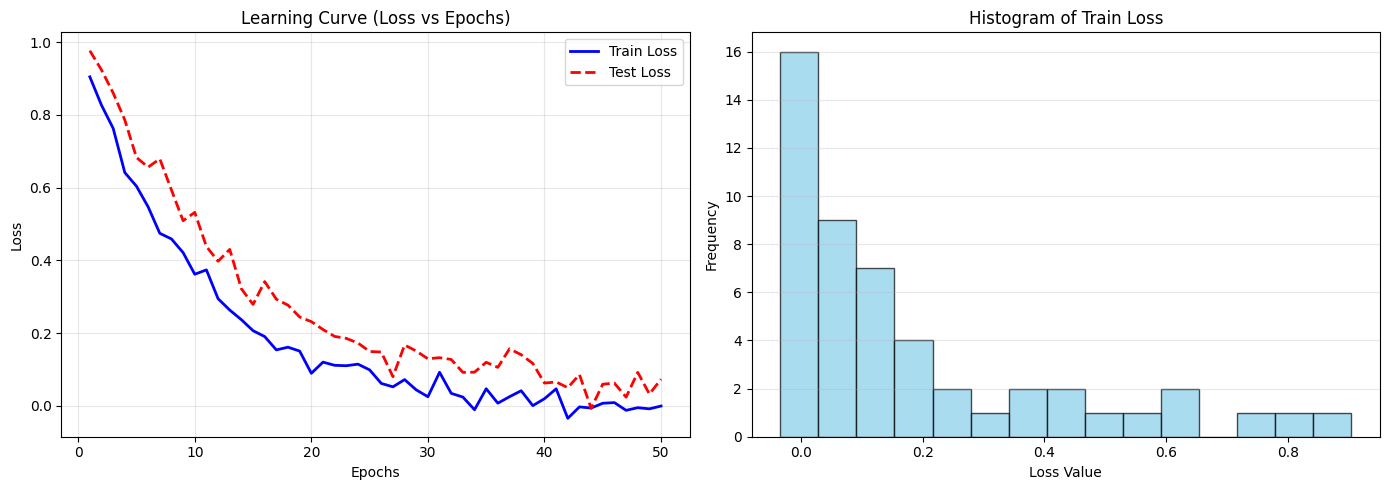

In [51]:
plt.figure(figsize=(14, 5))

# Subplot 1: Learning Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', color='blue', lw=2)
plt.plot(epochs, test_loss, label='Test Loss', color='red', linestyle='--', lw=2)
plt.title('Learning Curve (Loss vs Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: Histogram of Train Loss
plt.subplot(1, 2, 2)
plt.hist(train_loss, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Train Loss')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Bài 5: Tổng hợp - Phân tích cụm Gaussian

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sinh dữ liệu từ 3 cụm Gaussian
np.random.seed(42)
std = 0.7

# Cụm A: (0, 0), 300 điểm
A_x = np.random.normal(0, std, 300)
A_y = np.random.normal(0, std, 300)

# Cụm B: (4, 0), 300 điểm
B_x = np.random.normal(4, std, 300)
B_y = np.random.normal(0, std, 300)

# Cụm C: (2, 4), 400 điểm
C_x = np.random.normal(2, std, 400)
C_y = np.random.normal(4, std, 400)

# 2. Đưa vào DataFrame
data = {
    'x': np.concatenate([A_x, B_x, C_x]),
    'y': np.concatenate([A_y, B_y, C_y]),
    'cluster': ['A']*300 + ['B']*300 + ['C']*400
}
df_clusters = pd.DataFrame(data)

# 3. Hiển thị thông tin cơ bản
display(df_clusters.sample(5))
print("\nSố lượng điểm mỗi cụm:")
print(df_clusters['cluster'].value_counts())

,x,y,cluster
749,1.842664,4.700732,C
771,3.198196,5.186536,C
71,1.076626,0.348599,A
899,2.414769,3.793164,C
242,0.353491,0.370863,A



Số lượng điểm mỗi cụm:
cluster
C    400
A    300
B    300
Name: count, dtype: int64


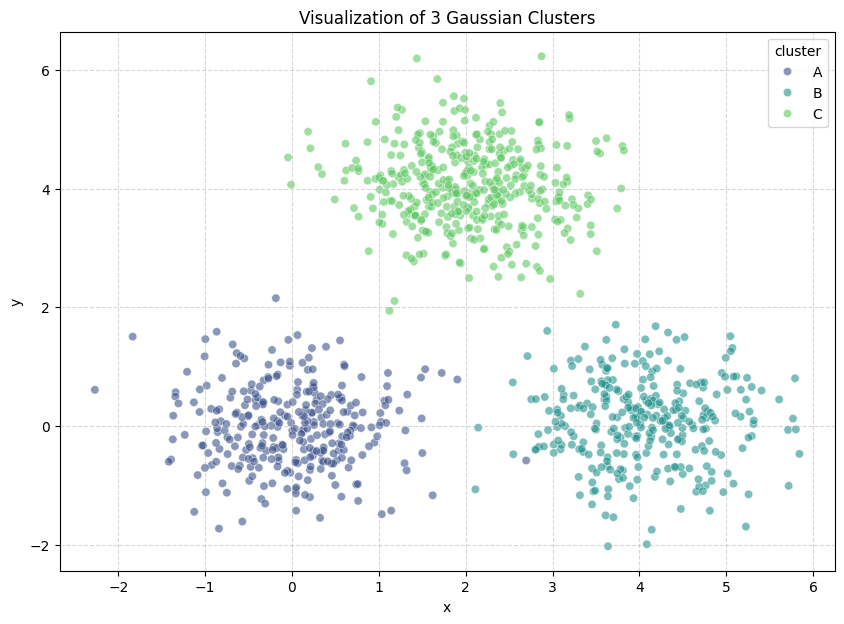

In [53]:
# 4. Vẽ scatter plot tô màu theo cụm
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_clusters, x='x', y='y', hue='cluster', palette='viridis', alpha=0.6)
plt.title('Visualization of 3 Gaussian Clusters')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [54]:
# 5. Tính trung bình x, y của mỗi cụm
cluster_means = df_clusters.groupby('cluster').mean()
print("Trung bình x, y của mỗi cụm (so sánh với tâm gốc [0,0], [4,0], [2,4]):")
display(cluster_means)

Trung bình x, y của mỗi cụm (so sánh với tâm gốc [0,0], [4,0], [2,4]):


,x,y
cluster,,
A,-0.003884,-0.015043
B,4.057536,0.068861
C,2.030802,4.046390
